In [1]:
# Cell -1 — Install Dependencies
import subprocess, sys
# [PATCH 7] Ensure all required packages are available
packages = [
    'timm>=1.0.0', 'scikit-learn', 'scipy', 'openpyxl', 'tqdm',
    'opencv-python-headless', 'seaborn',
]
subprocess.run([sys.executable, '-m', 'pip', 'install'] + packages, check=True)
print('[FOUND] All dependencies installed OK.')

import os
os.environ["HF_HUB_OFFLINE"] = "1"

[FOUND] All dependencies installed OK.


In [2]:
# Cell 0 - Configuration
import os
from pathlib import Path
import torch

# Environment
IS_KAGGLE  = os.path.exists("/kaggle/input")
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
KAGGLE_DATASET_SLUG = "BDC2026-20260704T072647Z-3-001"

# Data Constants
N_SPLITS   = 5
SEED       = 42
NUM_WORKERS= 4
OVERWRITE_MANIFEST = False

# Model 1: ConvNeXt V2-Tiny @ 512px
MODEL_NAME_CNN = "convnextv2_tiny.fcmae_ft_in22k_in1k_384"
IMG_SIZE_CNN   = 512
BATCH_SIZE_CNN = 32
BACKBONE_LR_CNN = 1e-5
EMA_DECAY_CNN    = 0.999
TTA_PASSES_CNN = 12

# Model 2: DINOv2-Small @ 518px
MODEL_NAME_VIT = "vit_small_patch14_dinov2.lvd142m"
IMG_SIZE_VIT   = 518
BATCH_SIZE_VIT = 32
BACKBONE_LR_VIT = 5e-6
EMA_DECAY_VIT    = 0.9995
TTA_PASSES_VIT = 8
SKIP_DINOV2_TRAINING = True

# Model 3: EVA-02-Base @ 448px
MODEL_NAME_EVA = "eva02_base_patch14_448.mim_in22k_ft_in1k"
IMG_SIZE_EVA   = 448
BATCH_SIZE_EVA = 24
BACKBONE_LR_EVA = 5e-6
EMA_DECAY_EVA    = 0.9998
TTA_PASSES_EVA = 8

# Model 4: SigLIP-SO400M @ 384px
MODEL_NAME_SIG  = "vit_so400m_patch14_siglip_384.webli"
IMG_SIZE_SIG    = 384
BATCH_SIZE_SIG  = 16 if (torch.cuda.is_available() and torch.cuda.get_device_properties(0).total_memory > 20e9) else 8
BACKBONE_LR_SIG = 2e-6
EMA_DECAY_SIG   = 0.9999
TTA_PASSES_SIG  = 8
NUM_EPOCHS_SIG  = 25

# Pseudo-Labeling & KD Hyperparameters
USE_PSEUDO_LABELING = True
PSEUDO_CONF_THRESH  = 0.95
KD_TEMPERATURE      = 2.0
KD_ALPHA            = 0.5

# Shared Hyperparameters
HEAD_LR            = 1e-4
WEIGHT_DECAY       = 0.05
NUM_EPOCHS         = 40
WARMUP_STEPS_RATIO = 0.05
LABEL_SMOOTHING    = 0.1
GRADIENT_CLIP_NORM = 1.0
EARLY_STOPPING_PATIENCE = 7
EARLY_STOPPING_MIN_DELTA = 0.0005

# Initial Weights Placeholder
ENSEMBLE_WEIGHT_CNN = 0.35
ENSEMBLE_WEIGHT_VIT = 0.25
ENSEMBLE_WEIGHT_EVA = 0.25
ENSEMBLE_WEIGHT_SIG = 0.15

# Class Mapping
CLASS_FOLDERS = ["0_Recyclable", "1_Electronic", "2_Organic"]
LABEL_MAP     = {0: "Recyclable", 1: "Electronic", 2: "Organic"}
LABEL_TO_IDX  = {"0_Recyclable": 0, "1_Electronic": 1, "2_Organic": 2}

# Data Integrity Constants
EXPECTED_TRAIN_COUNT   = 26527
EXPECTED_TEST_COUNT    = 1458
EXPECTED_OVERLAP_COUNT = 97
EXPECTED_CV_POOL_SIZE  = 26281

# [PATCH] Konstanta yang disesuaikan dengan dataset aktual
EXPECTED_NEAR_DUP_COUNT = 2
INITIAL_MISLABEL_EXCLUDE_FILES = []
EXPECTED_CV_EXCLUDE = 97
EXPECTED_TRAINING_EXCLUDE = 0 + 56  # 0 initial + 56 DROP_NOISE
APPLY_B3_CLEANING = False

RUN_ID = f"satria_v8_4model_{NUM_EPOCHS}ep_seed{SEED}"

print(f"Config loaded. Execution Device: {DEVICE.upper()}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print(f"SigLIP Batch Size: {BATCH_SIZE_SIG}")

Config loaded. Execution Device: CUDA
GPU: NVIDIA GeForce RTX 4090
VRAM: 25.26 GB
SigLIP Batch Size: 16


In [3]:
# Cell 1 - Environment Setup
import shutil

def find_train_dir(root: Path):
    if not root.exists():
        return None
    for check_dir in root.rglob("*"):
        if check_dir.is_dir() and check_dir.name == "train":
            return check_dir.parent
    return None

if IS_KAGGLE:
    input_root = Path("/kaggle/input")
    candidate_root = input_root / KAGGLE_DATASET_SLUG
    DATA_DIR = None
    if candidate_root.exists():
        DATA_DIR = find_train_dir(candidate_root)
        if DATA_DIR is None:
            DATA_DIR = candidate_root
    if DATA_DIR is None or not (DATA_DIR / "train").exists():
        for d in input_root.iterdir():
            found = find_train_dir(d)
            if found is not None:
                DATA_DIR = found
                break
    if DATA_DIR is None:
        raise FileNotFoundError("[ERROR] Could not auto-detect DATA_DIR on Kaggle.")
    OUTPUT_DIR = Path("/kaggle/working")
else:
    current_dir = Path.cwd()
    DATA_DIR = None
    check_dir = current_dir
    while check_dir != check_dir.parent:
        if "satria-data-bdc" in check_dir.name.lower():
            DATA_DIR = check_dir
            break
        check_dir = check_dir.parent
    if DATA_DIR is None:
        DATA_DIR = current_dir
        print(f"[WARNING] satria-data-bdc not found in parent chain. Using cwd: {current_dir}")
    OUTPUT_DIR = DATA_DIR / "outputs"

# [PATCH 5] Ensure all required output directories exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "logs").mkdir(exist_ok=True)
(OUTPUT_DIR / "cache").mkdir(exist_ok=True)

TRAIN_DIR       = DATA_DIR / "train"
TEST_DIR        = DATA_DIR / "test"
SUBMISSION_PATH = DATA_DIR / "submission.csv"

# [PATCH 7] Pre-flight validation — report missing assets clearly
_preflight_ok = True
for _path, _label in [
    (TRAIN_DIR, 'train/'),
    (TEST_DIR, 'test/'),
    (SUBMISSION_PATH, 'submission.csv'),
]:
    if _path.exists():
        print(f"[FOUND] {_label}: {_path}")
    else:
        print(f"[ERROR] {_label} MISSING: {_path}")
        _preflight_ok = False
if not _preflight_ok:
    raise FileNotFoundError('[ERROR] One or more required dataset paths are missing. See above.')

print(f"[FOUND] Environment  : {'Kaggle' if IS_KAGGLE else 'Vast.ai / Local'}")
print(f"[FOUND] DATA_DIR     : {DATA_DIR}")
print(f"[FOUND] OUTPUT_DIR   : {OUTPUT_DIR}")
print(f"[FOUND] Train files  : {len(list(TRAIN_DIR.rglob('*.*'))):,}")
print(f"[FOUND] Test files   : {len(list(TEST_DIR.rglob('*.*'))):,}")

[FOUND] train/: /workspace/satria-data-bdc/train
[FOUND] test/: /workspace/satria-data-bdc/test
[FOUND] submission.csv: /workspace/satria-data-bdc/submission.csv
[FOUND] Environment  : Vast.ai / Local
[FOUND] DATA_DIR     : /workspace/satria-data-bdc
[FOUND] OUTPUT_DIR   : /workspace/satria-data-bdc/outputs
[FOUND] Train files  : 26,527
[FOUND] Test files   : 1,458


In [4]:
# Cell 2 - Library Imports
import sys
import copy
import json
import time
import math
import random
import warnings
import logging
import tempfile
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode

import timm
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
from sklearn.model_selection import StratifiedGroupKFold
from tqdm.auto import tqdm
import cv2
import hashlib
import re
from scipy.optimize import minimize

warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = True

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger(__name__)

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

# === HACK: Menghilangkan "AssertionError: can only test a child process" ===
import multiprocessing
_original_is_alive = multiprocessing.Process.is_alive
def _safe_is_alive(self):
    if getattr(self, '_parent_pid', None) != os.getpid():
        return False
    return _original_is_alive(self)
multiprocessing.Process.is_alive = _safe_is_alive
# ===========================================================================

assert torch.__version__ >= "2.0.0"
assert timm.__version__ >= "0.9.0"

print(f"Libraries loaded.")
print(f"  torch  : {torch.__version__}")
print(f"  timm   : {timm.__version__}")

Libraries loaded.
  torch  : 2.11.0+cu128
  timm   : 1.0.28


In [5]:
# Cell 3 - MD5 Duplicate Detection
def compute_file_hash(file_path, chunk_size=8192):
    hasher = hashlib.md5()
    with open(file_path, "rb") as f:
        while chunk := f.read(chunk_size):
            hasher.update(chunk)
    return hasher.hexdigest()

def hash_all(root_dirs: dict, exts=None):
    if exts is None:
        exts = {".jpg", ".jpeg", ".png"}
    hash_map = defaultdict(list)
    all_files = []
    for label, folder in root_dirs.items():
        folder = Path(folder)
        for fp in sorted(folder.rglob("*")):
            if fp.is_file() and fp.suffix.lower() in exts:
                h = compute_file_hash(fp)
                hash_map[h].append((label, str(fp)))
                all_files.append((label, fp))
    return hash_map, all_files

TRAIN_DIRS = {
    "0_Recyclable": DATA_DIR / "train" / "0_Recyclable",
    "1_Electronic": DATA_DIR / "train" / "1_Electronic",
    "2_Organic":    DATA_DIR / "train" / "2_Organic",
}
TEST_DIR_MAP = {"test": DATA_DIR / "test"}

OVERLAP_CSV     = OUTPUT_DIR / "train_test_overlap.csv"
DUP_GROUPS_CSV  = OUTPUT_DIR / "train_duplicate_groups.csv"
NEAR_DUP_CSV    = OUTPUT_DIR / "near_duplicate_candidates.csv"

if not OVERWRITE_MANIFEST and OVERLAP_CSV.exists() and DUP_GROUPS_CSV.exists() and NEAR_DUP_CSV.exists():
    print("Loading pre-computed duplicate CSVs (OVERWRITE_MANIFEST=False)...")
    overlap_df   = pd.read_csv(OVERLAP_CSV)
    groups_df    = pd.read_csv(DUP_GROUPS_CSV)
    near_dup_df  = pd.read_csv(NEAR_DUP_CSV)
else:
    if OVERWRITE_MANIFEST:
        print("OVERWRITE_MANIFEST=True. Forcing hash recomputation from scratch...")
    else:
        print("Computing hashes from scratch (this may take a few minutes)...")
        
    print("  Hashing train...")
    train_hashes, train_files = hash_all(TRAIN_DIRS)
    print("  Hashing test...")
    test_hashes, _            = hash_all(TEST_DIR_MAP)

    overlap_rows = []
    for h, train_entries in train_hashes.items():
        if h in test_hashes:
            for (train_label, train_path) in train_entries:
                for (_, test_path) in test_hashes[h]:
                    overlap_rows.append({
                        "md5": h, "train_label": train_label, "train_path": train_path,
                        "train_filename": Path(train_path).name, "test_path": test_path,
                        "test_id": int(Path(test_path).stem),
                    })
    overlap_df = pd.DataFrame(overlap_rows)
    overlap_df.to_csv(OVERLAP_CSV, index=False)

    group_rows = []
    group_id   = 0
    for h, entries in train_hashes.items():
        if len(entries) > 1:
            group_id += 1
            labels_in_group = set(label for label, _ in entries)
            is_cross_class  = len(labels_in_group) > 1
            for (label, path) in entries:
                group_rows.append({
                    "md5": h, "duplicate_group_id": group_id, "label": label,
                    "filepath": path, "filename": Path(path).name,
                    "is_cross_class_group": is_cross_class, "match_type": "exact_md5",
                })
    groups_df = pd.DataFrame(group_rows)
    groups_df.to_csv(DUP_GROUPS_CSV, index=False)

    copy_pattern = re.compile(r"^(.*)\((\d+)\)(\.\w+)$")
    name_to_path = {fp.name: (label, fp) for label, fp in train_files}
    candidates   = []
    for label, fp in train_files:
        m = copy_pattern.match(fp.name)
        if m:
            base_name = m.group(1) + m.group(3)
            if base_name in name_to_path:
                orig_label, orig_fp = name_to_path[base_name]
                h_copy = compute_file_hash(fp)
                h_orig = compute_file_hash(orig_fp)
                candidates.append({
                    "file_a": fp.name, "file_b": base_name, "label_a": label,
                    "label_b": orig_label, "md5_match": h_copy == h_orig,
                    "path_a": str(fp), "path_b": str(orig_fp),
                })
    cand_df    = pd.DataFrame(candidates)
    near_dup_df = cand_df[~cand_df["md5_match"]].reset_index(drop=True) if len(cand_df) > 0 else pd.DataFrame()
    near_dup_df.to_csv(NEAR_DUP_CSV, index=False)
    print("  Done - CSVs saved.")

print(f"\nTrain-test overlap       : {len(overlap_df)} pairs  (expected {EXPECTED_OVERLAP_COUNT})")
print(f"Exact-MD5 dup groups     : {groups_df['duplicate_group_id'].nunique()} groups")
print(f"Near-duplicate candidates: {len(near_dup_df)} pairs  (expected {EXPECTED_NEAR_DUP_COUNT})")

assert len(overlap_df) == EXPECTED_OVERLAP_COUNT
assert len(near_dup_df) == EXPECTED_NEAR_DUP_COUNT

if 'train_files' not in locals():
    _, train_files = hash_all(TRAIN_DIRS)
    name_to_path = {fp.name: (label, fp) for label, fp in train_files}
    copy_pattern = re.compile(r"^(.*)\((\d+)\)(\.\w+)$")

orphan_copies = []
for label, fp in train_files:
    m = copy_pattern.match(fp.name)
    if m and (m.group(1) + m.group(3)) not in name_to_path:
        orphan_copies.append({"filename": fp.name, "filepath": str(fp)})

if orphan_copies:
    print(f"WARNING: Orphan copies (original missing): {len(orphan_copies)}")
    for o in orphan_copies[:10]:
        print(f"    {o['filename']}")

Loading pre-computed duplicate CSVs (OVERWRITE_MANIFEST=False)...

Train-test overlap       : 97 pairs  (expected 97)
Exact-MD5 dup groups     : 62 groups
Near-duplicate candidates: 2 pairs  (expected 2)
    IMG-20200328-WA0048(1).jpg
    IMG_20200329_152840(1).jpg
    maxresdefault (1).jpg
    unnamed (1).jpg


In [6]:
# Cell 4 - Build Master Manifest
NEAR_DUP_GROUP_START = 900_000

LABEL_MAP_FOLDER = {
    "0_Recyclable": 0,
    "1_Electronic":  1,
    "2_Organic":     2,
}

records = []
for folder in sorted((DATA_DIR / "train").iterdir()):
    if not folder.is_dir(): continue
    if folder.name not in LABEL_MAP_FOLDER: continue
    label_id = LABEL_MAP_FOLDER[folder.name]
    for fp in sorted(folder.glob("*")):
        if fp.is_file():
            records.append({
                "filename": fp.name, "filepath": str(fp),
                "label": label_id, "label_folder": folder.name,
            })

train_master = pd.DataFrame(records)
assert len(train_master) == EXPECTED_TRAIN_COUNT

train_master["duplicate_group_id"] = range(len(train_master))

filename_to_group = dict(zip(groups_df["filename"], groups_df["duplicate_group_id"]))
offset = train_master["duplicate_group_id"].max() + 1
filename_to_group = {k: v + offset for k, v in filename_to_group.items()}

train_master["duplicate_group_id"] = train_master.apply(
    lambda row: filename_to_group.get(row["filename"], row["duplicate_group_id"]), axis=1
)

if len(near_dup_df) > 0:
    near_dup_pairs = list(near_dup_df[["file_a", "file_b"]].itertuples(index=False, name=None))
    for i, (fa, fb) in enumerate(near_dup_pairs):
        gid  = NEAR_DUP_GROUP_START + i
        mask = train_master["filename"].isin([fa, fb])
        matched = train_master.loc[mask, "filename"].tolist()
        if len(matched) != 2: continue
        train_master.loc[mask, "duplicate_group_id"] = gid

overlap_filenames = set(overlap_df["train_filename"])
INITIAL_MISLABEL_EXCLUDE = INITIAL_MISLABEL_EXCLUDE_FILES

train_master["exclude_from_cv"]       = train_master["filename"].isin(overlap_filenames)
train_master["exclude_from_training"] = train_master["filename"].isin(INITIAL_MISLABEL_EXCLUDE)

print(f"\nexclude_from_cv       : {train_master['exclude_from_cv'].sum()}  (expected {EXPECTED_CV_EXCLUDE})")
print(f"exclude_from_training : {train_master['exclude_from_training'].sum()}  (expected {len(INITIAL_MISLABEL_EXCLUDE_FILES)})")

train_master.to_csv(OUTPUT_DIR / "train_master_with_groups.csv", index=False)
print("\ntrain_master_with_groups.csv saved.")


exclude_from_cv       : 97  (expected 97)
exclude_from_training : 0  (expected 0)

train_master_with_groups.csv saved.


In [7]:
# Cell 5 - Batch Data Cleaning
print("Applying Batch Data Cleaning (Relabels & Drops)...")

backup_path = OUTPUT_DIR / "train_master_PRE_CLEANING_BACKUP.csv"
train_master.to_csv(backup_path, index=False)

BATCH1_RELABEL_MAP = {
    "R_3825.jpg": 1, "R_3733.jpg": 1, "O_7776.jpg": 1, "battery_61.jpg": 0,
}

for filename, new_label in BATCH1_RELABEL_MAP.items():
    mask = train_master["filename"] == filename
    if mask.sum() == 0: continue
    old_label = train_master.loc[mask, "label"].values[0]
    train_master.loc[mask, "label"] = new_label

RELABEL_TO_RECYCLABLE = [
    "R_386.jpg", "R_8257.jpg", "R_2067.jpg", "R_6246.jpg", "R_9577.jpg", "R_531.jpg", "R_600.jpg", "R_5929.jpg",
    "O_1892.jpg", "O_6271.jpg", "O_1598.jpg", "O_1876.jpg", "O_5084.jpg", "O_5263.jpg", "O_262.jpg", "O_1666.jpg",
    "O_6852.jpg", "O_1783.jpg", "O_6812.jpg", "O_9175.jpg", "O_5295.jpg", "O_1909.jpg", "O_8864.jpg", "O_6629.jpg",
    "O_454.jpg", "O_4910.jpg", "O_1816.jpg", "O_6757.jpg", "O_1494.jpg", "O_1556.jpg", "O_1807.jpg", "O_10473.jpg",
    "O_5225.jpg", "O_1949.jpg", "O_712.jpg", "O_10014.jpg", "O_6841.jpg", "O_1888.jpg", "O_9183.jpg", "O_5257.jpg",
    "O_7969.jpg", "O_1635.jpg", "O_6640.jpg", "O_1625.jpg", "O_517.jpg", "O_7248.jpg", "O_1538.jpg", "O_1800.jpg",
    "O_345.jpg", "O_5259.jpg",
]
RELABEL_TO_ORGANIC = [
    "R_566.jpg", "R_9775.jpg", "R_2451.jpg", "R_8580.jpg", "R_9817.jpg","R_6057.jpg", "R_9828.jpg", "R_4815.jpg",
]

DROP_NOISE = [
    "R_9957.jpg", "R_4583.jpg", "R_850.jpg", "R_4638.jpg", "R_8327.jpg", "R_2909.jpg", "R_6142.jpg", "R_4602.jpg",
    "R_5044.jpg", "R_6228.jpg", "R_759.jpg", "R_258.jpg", "R_6054.jpg", "R_8315.jpg", "R_6087.jpg", "R_4841.jpg",
    "R_6935.jpg", "R_4090.jpg", "R_891.jpg", "R_2835.jpg", "R_6092.jpg", "R_4413.jpg", "R_2786.jpg", "R_4198.jpg",
    "R_4626.jpg", "R_810.jpg", "R_509.jpg", "R_548.jpg", "R_4046.jpg", "O_8835.jpg", "O_1345.jpg", "O_221.jpg",
    "O_572.jpg", "O_6751.jpg", "O_10358.jpg","O_11223.jpg","O_1263.jpg", "O_9569.jpg", "O_1627.jpg", "O_7628.jpg",
    "O_10298.jpg","O_4286.jpg", "O_8924.jpg", "O_6391.jpg", "O_9746.jpg", "O_5376.jpg", "O_6755.jpg", "O_9919.jpg",
    "O_3948.jpg", "O_5017.jpg", "O_1935.jpg", "O_3621.jpg", "O_1864.jpg", "O_162.jpg", "O_10400.jpg","O_11423.jpg",
]

def apply_relabels(df, filenames, new_label, batch_name, not_found_list=None):
    applied = 0
    for fn in filenames:
        mask = df["filename"] == fn
        if mask.sum() == 0:
            if not_found_list is not None: not_found_list.append(fn)
            continue
        df.loc[mask, "label"] = new_label
        applied += 1
    return not_found_list or []

not_found = apply_relabels(train_master, RELABEL_TO_RECYCLABLE, 0, "-> Recyclable")
not_found = apply_relabels(train_master, RELABEL_TO_ORGANIC, 2, "-> Organic")

drop_set = set(DROP_NOISE)
drop_applied = train_master["filename"].isin(drop_set)
train_master.loc[drop_applied, "exclude_from_training"] = True

# [PATCH] Fix hardcode print
total_training_excluded = train_master["exclude_from_training"].sum()
print(f"  DROP_NOISE   : {drop_applied.sum()}/{len(DROP_NOISE)} files marked exclude_from_training")
print(f"\nexclude_from_training : {total_training_excluded}  ({len(INITIAL_MISLABEL_EXCLUDE_FILES)} initial + {len(DROP_NOISE)} noise = {len(INITIAL_MISLABEL_EXCLUDE_FILES)+len(DROP_NOISE)} total)")

if APPLY_B3_CLEANING:
    b3_xlsx = OUTPUT_DIR / "oof_high_confidence_errors (LABELED).xlsx"
    if not b3_xlsx.exists():
        b3_xlsx = DATA_DIR.parent / "Submisison 1" / "oof_high_confidence_errors (LABELED).xlsx"
    if b3_xlsx.exists():
        b3_df = pd.read_excel(b3_xlsx)
        already_cleaned = set(train_master['filename'].str.strip())
        raw = b3_df['is_relabeled'].astype(str).str.strip().str.upper()
        b3_df['verdict'] = raw.map(lambda x: 'DROP' if x == 'DROP' else 'RELABEL' if x in ('TRUE', '1', 'YES') else 'CORRECT')
        b3_drops = b3_df[(b3_df['verdict'] == 'DROP') & b3_df['filename'].str.strip().isin(already_cleaned)]
        b3_relabels = b3_df[(b3_df['verdict'] == 'RELABEL') & b3_df['filename'].str.strip().isin(already_cleaned)]
        drop_names = set(b3_drops['filename'].str.strip())
        drop_mask = train_master['filename'].str.strip().isin(drop_names)
        train_master.loc[drop_mask, 'exclude_from_training'] = True
        train_master.loc[drop_mask, 'exclude_from_cv'] = True
        for _, row in b3_relabels.iterrows():
            mask = train_master['filename'].str.strip() == row['filename'].strip()
            if mask.sum() > 0:
                train_master.loc[mask, 'label'] = int(row['oof_pred'])

Applying Batch Data Cleaning (Relabels & Drops)...
  DROP_NOISE   : 56/56 files marked exclude_from_training

exclude_from_training : 56  (0 initial + 56 noise = 56 total)


In [8]:
# Cell 6 - StratifiedGroupKFold 5-Fold Split
cv_pool = train_master[(~train_master["exclude_from_cv"]) & (~train_master["exclude_from_training"])].reset_index(drop=True).copy()

sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
cv_pool["fold"] = -1
X, y, groups = cv_pool["filename"], cv_pool["label"], cv_pool["duplicate_group_id"]

for fold_idx, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups)):
    cv_pool.loc[val_idx, "fold"] = fold_idx

assert (cv_pool["fold"] == -1).sum() == 0
group_fold_check = cv_pool.groupby("duplicate_group_id")["fold"].nunique()
assert len(group_fold_check[group_fold_check > 1]) == 0, "GROUP LEAKAGE!"

fold_map = dict(zip(cv_pool["filename"], cv_pool["fold"]))
train_master["fold"] = train_master["filename"].map(fold_map).fillna(-1).astype(int)

train_master.to_csv(OUTPUT_DIR / "train_master_with_folds.csv", index=False)
print(f"train_master_with_folds.csv saved -> {OUTPUT_DIR}")

train_master_with_folds.csv saved -> /workspace/satria-data-bdc/outputs


In [9]:
# Cell 7 - Integrity Assertions
assert len(train_master) == EXPECTED_TRAIN_COUNT
assert train_master["filename"].duplicated().sum() == 0
assert train_master["exclude_from_cv"].sum() == EXPECTED_CV_EXCLUDE
assert train_master["exclude_from_training"].sum() == EXPECTED_TRAINING_EXCLUDE
assert train_master[(~train_master["exclude_from_cv"]) & (~train_master["exclude_from_training"])]["fold"].min() >= 0

eligible = train_master[~train_master["exclude_from_training"]]
missing = eligible[~eligible["filepath"].apply(lambda p: Path(p).exists())]
assert len(missing) == 0

random.seed(SEED)
spot_check_files = random.sample(eligible["filepath"].tolist(), 50)
load_errors = []
for fp in spot_check_files:
    try:
        with Image.open(fp) as img: img.verify()
    except Exception as e:
        load_errors.append((fp, str(e)))
assert len(load_errors) == 0
print("ALL DATA PIPELINE ASSERTIONS PASSED.")

ALL DATA PIPELINE ASSERTIONS PASSED.


In [10]:
# Cell 8 - Test Set Loader Setup
submission_df = pd.read_csv(SUBMISSION_PATH)
assert list(submission_df.columns) == ["id", "predicted"]

test_files_ordered = []
for row in submission_df.itertuples(index=False):
    img_path = TEST_DIR / f"{int(row.id)}.jpg"
    assert img_path.exists(), f"Missing test file: {img_path}"
    test_files_ordered.append(str(img_path))

submission_df["filepath"] = test_files_ordered
print(f"All {len(test_files_ordered)} test files found on disk.")

All 1458 test files found on disk.


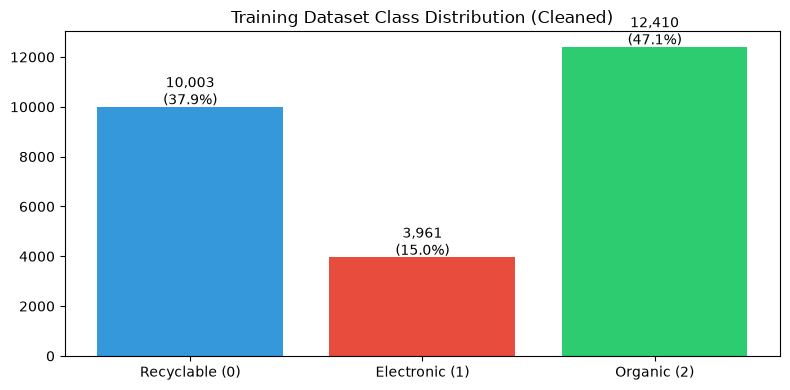

In [11]:
# Cell 9 - Class Distribution and Sample Grid
valid_train = train_master[(~train_master["exclude_from_cv"]) & (~train_master["exclude_from_training"])]

plt.figure(figsize=(8, 4))
dist = valid_train["label"].value_counts().sort_index()
bars = plt.bar(["Recyclable (0)", "Electronic (1)", "Organic (2)"], dist.values, color=["#3498db", "#e74c3c", "#2ecc71"])
plt.title("Training Dataset Class Distribution (Cleaned)")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 100, f"{yval:,}\n({yval/len(valid_train):.1%})", ha="center")
plt.tight_layout()
plt.show()

In [12]:
# Cell 10 - Electronic Bimodal Analysis
electronic_files = valid_train[valid_train["label"] == 1]["filepath"].tolist()
n_icon_150 = 0
n_natural  = 0
icon_samples = []
natural_samples = []

for fp in electronic_files:
    try:
        with Image.open(fp) as img:
            w, h = img.size
            if w == 150 and h == 150:
                n_icon_150 += 1
                if len(icon_samples) < 5: icon_samples.append(fp)
            else:
                n_natural += 1
                if len(natural_samples) < 5: natural_samples.append(fp)
    except: pass

print(f"150x150 Icons : {n_icon_150} ({n_icon_150/(n_icon_150+n_natural):.1%})")
print(f"Natural Photos: {n_natural} ({n_natural/(n_icon_150+n_natural):.1%})")

150x150 Icons : 2657 (67.1%)
Natural Photos: 1304 (32.9%)


In [13]:
# Cell 11 - Image Quality and Format Analysis
file_sizes = []
extensions = set()
truncated_files = []

for fp in valid_train["filepath"]:
    try:
        ext = Path(fp).suffix.lower()
        extensions.add(ext)
        size = os.path.getsize(fp)
        file_sizes.append({"filepath": fp, "size_kb": size / 1024, "label": train_master[train_master["filepath"] == fp]["label"].values[0]})
        with Image.open(fp) as img: img.load()
    except Exception as e:
        truncated_files.append({"filepath": fp, "error": str(e)})

assert extensions.issubset({".jpg", ".jpeg", ".png"})
print("No truncated or corrupt images detected." if not truncated_files else f"WARNING: {len(truncated_files)} corrupt images.")

No truncated or corrupt images detected.


In [14]:
# Cell 12 - Shortcut Risk Analysis
def compute_background_complexity(img_path, patch_size=30):
    try:
        img = Image.open(img_path).convert("RGB")
        arr = np.array(img)
        h, w, _ = arr.shape
        p = patch_size
        corners = [arr[0:p, 0:p], arr[0:p, w-p:w], arr[h-p:h, 0:p], arr[h-p:h, w-p:w]]
        return np.mean([c.var() for c in corners])
    except: return np.nan

random.seed(SEED)
bg_results = []
for label_id in [0, 1, 2]:
    subset = valid_train[valid_train["label"] == label_id]["filepath"].tolist()
    samples = random.sample(subset, min(500, len(subset)))
    for fp in samples:
        bg_results.append({"class": LABEL_MAP[label_id], "bg_variance": compute_background_complexity(fp)})

df_bg = pd.DataFrame(bg_results).dropna()
df_bg["is_plain_bg"] = df_bg["bg_variance"] < 50
print("Proportion of plain-background images (variance < 50):")
print(df_bg.groupby("class")["is_plain_bg"].mean().apply(lambda x: f"{x:.1%}"))

Proportion of plain-background images (variance < 50):
class
Electronic    15.4%
Organic       18.0%
Recyclable    36.0%
Name: is_plain_bg, dtype: str


In [15]:
# Cell 13 - Transforms and Dataset Classes
def load_image_as_rgb(fp):
    return Image.open(fp).convert("RGB")

def get_transforms(img_size):
    mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
    train_tfm = T.Compose([
        T.Resize((img_size, img_size), interpolation=InterpolationMode.BICUBIC),
        T.RandomHorizontalFlip(0.5), T.RandAugment(num_ops=2, magnitude=9),
        T.ColorJitter(brightness=0.2, contrast=0.1, saturation=0.1),
        T.ToTensor(), T.Normalize(mean=mean, std=std),
    ])
    eval_tfm = T.Compose([
        T.Resize((img_size, img_size), interpolation=InterpolationMode.BICUBIC),
        T.ToTensor(), T.Normalize(mean=mean, std=std),
    ])
    return train_tfm, eval_tfm

def get_transforms_clip(img_size):
    mean, std = [0.5, 0.5, 0.5], [0.5, 0.5, 0.5]
    train_tfm = T.Compose([
        T.Resize((img_size, img_size), interpolation=InterpolationMode.BICUBIC),
        T.RandomHorizontalFlip(0.5), T.RandAugment(num_ops=2, magnitude=9),
        T.ColorJitter(brightness=0.2, contrast=0.1, saturation=0.1),
        T.ToTensor(), T.Normalize(mean=mean, std=std),
    ])
    eval_tfm = T.Compose([
        T.Resize((img_size, img_size), interpolation=InterpolationMode.BICUBIC),
        T.ToTensor(), T.Normalize(mean=mean, std=std),
    ])
    return train_tfm, eval_tfm

class WasteDataset(Dataset):
    def __init__(self, df, transform=None, img_size=384):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.img_size = img_size

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        fp = row.get("filepath", None)
        if fp is None or not Path(fp).exists():
            folder = row.get("label_folder", CLASS_FOLDERS[int(row["label"])])
            fp = TRAIN_DIR / folder / row["filename"]
        img = load_image_as_rgb(fp)
        if self.transform: img = self.transform(img)
        return img, int(row["label"])

class WasteDatasetWithPseudo(Dataset):
    def __init__(self, train_df, pseudo_df=None, transform=None, use_pseudo=True, pseudo_conf_thresh=0.95):
        self.transform = transform
        real = train_df[(~train_df["exclude_from_training"].astype(bool))].copy()
        real["is_pseudo"] = False
        real["soft_R"], real["soft_E"], real["soft_O"] = 0.0, 0.0, 0.0

        if use_pseudo and pseudo_df is not None and len(pseudo_df) > 0:
            pseudo = pseudo_df[pseudo_df["confidence"] >= pseudo_conf_thresh].copy()
            pseudo["is_pseudo"] = True
            pseudo["label"] = pseudo["hard_label"]
            self.df = pd.concat([real, pseudo], ignore_index=True)
        else:
            self.df = real.reset_index(drop=True)

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        fp = row.get("filepath", None)
        if fp is None or not Path(fp).exists():
            folder = row.get("label_folder", CLASS_FOLDERS[int(row["label"])])
            fp = TRAIN_DIR / folder / row["filename"]
        img = load_image_as_rgb(fp)
        if self.transform: img = self.transform(img)
        label = int(row["label"])
        is_pseudo = bool(row["is_pseudo"])
        soft = torch.tensor([row.get("soft_R", 0.0), row.get("soft_E", 0.0), row.get("soft_O", 0.0)], dtype=torch.float32)
        return img, label, soft, is_pseudo

In [16]:
# Cell 14 - Model Builder, Optimizer, Scheduler, and KD Loss
def build_model(model_name, num_classes=3, pretrained=True, img_size=None):
    kwargs = {"pretrained": pretrained, "num_classes": num_classes}
    if img_size is not None: kwargs["img_size"] = img_size
    return timm.create_model(model_name, **kwargs)

def get_optimizer(model, backbone_lr, head_lr, weight_decay=WEIGHT_DECAY):
    backbone_params, head_params = [], []
    for name, param in model.named_parameters():
        if not param.requires_grad: continue
        if "head" in name or "fc" in name or "classifier" in name: head_params.append(param)
        else: backbone_params.append(param)
    return torch.optim.AdamW([
        {"params": backbone_params, "lr": backbone_lr},
        {"params": head_params,     "lr": head_lr}
    ], weight_decay=weight_decay)

def get_scheduler(optimizer, steps_per_epoch, num_epochs, warmup_ratio=WARMUP_STEPS_RATIO):
    total_steps  = steps_per_epoch * num_epochs
    warmup_steps = int(total_steps * warmup_ratio)
    def lr_lambda(current_step):
        if current_step < warmup_steps:
            return float(current_step) / float(max(1, warmup_steps))
        progress = float(current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

class KDLoss(nn.Module):
    def __init__(self, T=KD_TEMPERATURE, alpha=KD_ALPHA, label_smoothing=LABEL_SMOOTHING):
        super().__init__()
        self.T = T
        self.alpha = alpha
        self.ce = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
        self.kl = nn.KLDivLoss(reduction="batchmean")

    def forward(self, logits, hard_labels, soft_labels=None, is_pseudo=None):
        ce_loss = self.ce(logits, hard_labels)
        if soft_labels is None or is_pseudo is None or not is_pseudo.any(): return ce_loss
        pseudo_mask = is_pseudo.bool()
        p_logits = logits[pseudo_mask] / self.T
        p_soft   = soft_labels[pseudo_mask] ** (1.0 / self.T)
        p_soft   = p_soft / p_soft.sum(dim=1, keepdim=True)
        kd_loss  = self.kl(F.log_softmax(p_logits, dim=1), p_soft) * (self.T ** 2)
        return self.alpha * ce_loss + (1.0 - self.alpha) * kd_loss

In [17]:
# Cell 15 - Training Utilities
def update_ema(model, ema_model, decay=EMA_DECAY_CNN):
    with torch.no_grad():
        for ema_param, model_param in zip(ema_model.parameters(), model.parameters()):
            ema_param.data.mul_(decay).add_(model_param.data, alpha=1 - decay)

In [18]:
# Cell 16 - 5-Fold Training Runner
def train_one_epoch_kd(model, ema_model, loader, criterion, optimizer, scheduler, scaler, ema_decay):
    model.train()
    total_loss, total_norm = 0.0, 0.0
    for batch in tqdm(loader, leave=False, desc="Train"):
        if len(batch) == 4:
            imgs, labels, soft_labels, is_pseudo = batch
            soft_labels = soft_labels.to(DEVICE)
            is_pseudo   = is_pseudo.to(DEVICE)
        else:
            imgs, labels = batch
            soft_labels, is_pseudo = None, None

        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            logits = model(imgs)
            loss   = criterion(logits, labels, soft_labels, is_pseudo)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        norm = torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        with torch.no_grad():
            for p_ema, p_m in zip(ema_model.parameters(), model.parameters()):
                p_ema.data.mul_(ema_decay).add_(p_m.data, alpha=1.0 - ema_decay)

        total_loss += loss.item()
        total_norm += norm.item() if torch.isfinite(torch.tensor(norm)) else 0.0

    return {"loss": total_loss / len(loader), "grad_norm": total_norm / len(loader)}

@torch.no_grad()
def validate_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_probs, all_preds, all_labels = [], [], []

    for imgs, labels in tqdm(loader, leave=False, desc="Val"):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with torch.amp.autocast("cuda"):
            logits = model(imgs)
            loss   = criterion(logits, labels)
            probs  = F.softmax(logits, dim=1)

        total_loss += loss.item() * imgs.size(0)
        all_probs.append(probs.cpu().numpy())
        all_preds.append(torch.argmax(probs, dim=1).cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_probs  = np.concatenate(all_probs, axis=0)
    all_preds  = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    return {
        "loss": total_loss / len(loader.dataset),
        "macro_f1": f1_score(all_labels, all_preds, average="macro"),
        "f1_per_class": f1_score(all_labels, all_preds, average=None),
        "probs": all_probs, "preds": all_preds, "labels": all_labels,
    }

def run_5fold_training(model_name, img_size, prefix, batch_size, backbone_lr, head_lr, ema_decay,
                       get_tfm_fn=get_transforms, pseudo_df=None, num_epochs=NUM_EPOCHS):
    print(f"\nSTARTING TRAINING: {prefix} ({model_name} @ {img_size}px, epochs={num_epochs})\n")
    train_tfm, eval_tfm = get_tfm_fn(img_size)
    criterion = KDLoss(T=KD_TEMPERATURE, alpha=KD_ALPHA, label_smoothing=LABEL_SMOOTHING)

    oof_probs  = np.zeros((len(train_master), 3), dtype=np.float32)
    oof_labels = np.full((len(train_master)), -1, dtype=int)
    fold_results = {}

    progress_file = OUTPUT_DIR / f"{prefix}_kfold_progress.json"

    # [PATCH 1] Reconcile progress JSON with actual checkpoint files on disk
    completed_folds = []
    if progress_file.exists():
        with open(progress_file, "r") as f:
            completed_folds = json.load(f)
    _json_reported = set(completed_folds)
    _actually_done = set()
    for _fold_check in range(N_SPLITS):
        _pt = OUTPUT_DIR / f"{prefix}_fold{_fold_check}_best.pt"
        if _pt.exists() and _pt.stat().st_size > 1024:
            _actually_done.add(_fold_check)
    if _actually_done != _json_reported:
        print(f"[RECOVER] {prefix}: progress JSON says {sorted(_json_reported)} "
              f"but checkpoints found for {sorted(_actually_done)}. Repairing.")
        completed_folds = sorted(_actually_done)
        tmp_fd, tmp_path = tempfile.mkstemp(dir=OUTPUT_DIR)
        with os.fdopen(tmp_fd, 'w') as _f: json.dump(completed_folds, _f)
        os.replace(tmp_path, progress_file)
    if completed_folds:
        print(f"[SKIP] {prefix}: Folds {completed_folds} already complete — skipping.")

    for fold in range(N_SPLITS):
        if fold in completed_folds:
            ckpt_path = OUTPUT_DIR / f"{prefix}_fold{fold}_best.pt"
            # [PATCH 3] Guard against corrupted checkpoint files
            try:
                ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
                oof_probs[ckpt["val_indices"]]  = ckpt["best_probs"]
                oof_labels[ckpt["val_indices"]] = ckpt["best_labels"]
                fold_results[fold] = {
                    "best_f1": ckpt["best_f1"],
                    "best_per_class_f1": ckpt.get("best_per_class_f1", None),
                    "history": ckpt.get("history", {})
                }
                print(f"[LOAD] {prefix} fold {fold}: best_f1={ckpt['best_f1']:.4f}")
            except Exception as _e:
                print(f"[RECOVER] {prefix} fold {fold} checkpoint corrupted ({_e}). Will retrain.")
                completed_folds = [c for c in completed_folds if c != fold]
                tmp_fd, tmp_path = tempfile.mkstemp(dir=OUTPUT_DIR)
                with os.fdopen(tmp_fd, 'w') as _f: json.dump(completed_folds, _f)
                os.replace(tmp_path, progress_file)
            continue

        print(f"\n--- FOLD {fold+1}/{N_SPLITS} ---")
        train_df = train_master[(train_master["fold"] != fold) & (~train_master["exclude_from_training"].astype(bool))].copy()
        val_df   = train_master[(train_master["fold"] == fold) & (~train_master["exclude_from_training"].astype(bool))].copy()

        train_ds = WasteDatasetWithPseudo(train_df, pseudo_df, transform=train_tfm, use_pseudo=USE_PSEUDO_LABELING, pseudo_conf_thresh=PSEUDO_CONF_THRESH)
        val_ds   = WasteDataset(val_df, transform=eval_tfm, img_size=img_size)

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
        val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

        model = build_model(model_name, pretrained=True).to(DEVICE)
        ema_model = copy.deepcopy(model).eval().to(DEVICE)
        optimizer = get_optimizer(model, backbone_lr, head_lr)
        scheduler = get_scheduler(optimizer, len(train_loader), num_epochs)
        scaler    = torch.amp.GradScaler("cuda")

        best_f1, best_probs, best_labels = 0.0, None, None
        best_per_class = None
        history = defaultdict(list)
        es_counter = 0

        for epoch in range(num_epochs):
            t_start = time.time()
            train_res = train_one_epoch_kd(model, ema_model, train_loader, criterion, optimizer, scheduler, scaler, ema_decay)
            val_res   = validate_epoch(ema_model, val_loader, nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING))
            elapsed   = time.time() - t_start

            history["train_loss"].append(train_res["loss"])
            history["val_loss"].append(val_res["loss"])
            history["val_macro_f1"].append(val_res["macro_f1"])

            if val_res["macro_f1"] > best_f1 + EARLY_STOPPING_MIN_DELTA:
                es_counter = 0
                best_f1        = val_res["macro_f1"]
                best_probs     = val_res["probs"]
                best_labels    = val_res["labels"]
                best_per_class = val_res["f1_per_class"]
                torch.save({
                    "epoch": epoch + 1, "model_state_dict": ema_model.state_dict(),
                    "best_f1": best_f1, "best_probs": best_probs, "best_labels": best_labels,
                    "val_indices": val_df.index.to_numpy(), "best_per_class_f1": best_per_class,
                    "run_id": RUN_ID, "history": dict(history)
                }, OUTPUT_DIR / f"{prefix}_fold{fold}_best.pt")
                print(f"  -> Best saved! (F1: {best_f1:.4f})")
            else:
                es_counter += 1
                if es_counter >= EARLY_STOPPING_PATIENCE: break

        fold_results[fold] = {"best_f1": best_f1, "best_per_class_f1": best_per_class, "history": dict(history)}
        oof_probs[val_df.index]  = best_probs
        oof_labels[val_df.index] = best_labels

        completed_folds.append(fold)
        tmp_fd, tmp_path = tempfile.mkstemp(dir=OUTPUT_DIR)
        with os.fdopen(tmp_fd, "w") as f: json.dump(completed_folds, f)
        os.replace(tmp_path, progress_file)

        del model, ema_model, optimizer, scheduler, scaler
        torch.cuda.empty_cache()

    mean_cv = np.mean([fold_results[f]["best_f1"] for f in range(N_SPLITS)])
    print(f"\n{prefix.upper()} COMPLETE. 5-Fold Mean CV: {mean_cv:.4f}\n")
    return fold_results, oof_probs, oof_labels

In [49]:
# Cell 17 - EXECUTION: ConvNeXt Training
convnext_fold_results, convnext_oof_probs, convnext_oof_labels = run_5fold_training(
    model_name=MODEL_NAME_CNN, img_size=IMG_SIZE_CNN, prefix="convnext", 
    batch_size=BATCH_SIZE_CNN, backbone_lr=BACKBONE_LR_CNN, 
    head_lr=HEAD_LR, ema_decay=EMA_DECAY_CNN
)


STARTING TRAINING: convnext (convnextv2_tiny.fcmae_ft_in22k_in1k_384 @ 512px, epochs=40)

[SKIP] convnext: Folds [0, 1, 2, 3, 4] already complete — skipping.
[LOAD] convnext fold 0: best_f1=0.9841
[LOAD] convnext fold 1: best_f1=0.9851
[LOAD] convnext fold 2: best_f1=0.9878
[LOAD] convnext fold 3: best_f1=0.9852
[LOAD] convnext fold 4: best_f1=0.9895

CONVNEXT COMPLETE. 5-Fold Mean CV: 0.9863



In [50]:
# Cell 18 - DINOv2 @ 518px
if SKIP_DINOV2_TRAINING:
    print('[LOAD] Loading existing DINOv2 checkpoints (SKIP_DINOV2_TRAINING=True)...')
    vit_oof_probs  = np.zeros((len(train_master), 3), dtype=np.float32)
    vit_oof_labels = np.full((len(train_master),), -1, dtype=int)
    vit_fold_results = {}

    for fold in range(N_SPLITS):
        # [PATCH 2] Multi-path fallback for DINOv2 checkpoint discovery
        _dinov2_search_paths = [
            OUTPUT_DIR / f'dinov2_fold{fold}_best.pt',
            DATA_DIR / f'dinov2_fold{fold}_best.pt',
            Path('.') / f'dinov2_fold{fold}_best.pt',
            Path('.') / 'dinov2' / f'dinov2_fold{fold}_best.pt',
            DATA_DIR.parent / 'dinov2' / f'dinov2_fold{fold}_best.pt',
        ]
        ckpt_path = next((c for c in _dinov2_search_paths if c.exists() and c.stat().st_size > 1024), None)
        if ckpt_path is None:
            paths_str = '\n'.join(f'  {p}' for p in _dinov2_search_paths)
            raise FileNotFoundError(
                f'[ERROR] DINOv2 fold {fold} checkpoint not found in any of:\n'
                f'{paths_str}\n'
                f'[FIX] Copy dinov2_fold{fold}_best.pt to: {OUTPUT_DIR}'
            )
        # Auto-copy to OUTPUT_DIR so TTA cells can find it later
        _out_ckpt = OUTPUT_DIR / f'dinov2_fold{fold}_best.pt'
        if ckpt_path.resolve() != _out_ckpt.resolve() and not _out_ckpt.exists():
            import shutil as _shutil_d
            _shutil_d.copy2(ckpt_path, _out_ckpt)
            print(f'[LOAD] Copied {ckpt_path.name} to OUTPUT_DIR for TTA.')
        # [PATCH 3] Guard against corrupted checkpoint files
        _load_path = _out_ckpt if _out_ckpt.exists() else ckpt_path
        try:
            ckpt = torch.load(_load_path, map_location='cpu', weights_only=False)
        except Exception as _e:
            raise RuntimeError(
                f'[ERROR] DINOv2 fold {fold} checkpoint is corrupted: {_e}. '
                f'Delete {_load_path} and retrain.'
            ) from _e
        vit_oof_probs[ckpt['val_indices']]  = ckpt['best_probs']
        vit_oof_labels[ckpt['val_indices']] = ckpt['best_labels']
        vit_fold_results[fold] = {
            'best_f1': ckpt['best_f1'],
            'best_per_class_f1': ckpt.get('best_per_class_f1', [None, None, None]),
            'history': ckpt.get('history', {})
        }
        print(f'[LOAD] DINOv2 fold {fold}: best_f1={ckpt["best_f1"]:.4f} from {ckpt_path}')

    valid_mask = vit_oof_labels >= 0
    vit_oof_f1 = f1_score(vit_oof_labels[valid_mask], np.argmax(vit_oof_probs[valid_mask], axis=1), average='macro')
    print(f'[LOAD] DINOv2 loaded. Reconstructed OOF CV: {vit_oof_f1:.4f}')

else:
    print('[TRAIN] Retraining DINOv2 with cleaned data...')
    seed_everything(SEED)
    vit_fold_results, vit_oof_probs, vit_oof_labels = run_5fold_training(
        model_name=MODEL_NAME_VIT, img_size=IMG_SIZE_VIT, prefix='dinov2',
        batch_size=BATCH_SIZE_VIT, backbone_lr=BACKBONE_LR_VIT,
        head_lr=HEAD_LR, ema_decay=EMA_DECAY_VIT,
    )

[LOAD] Loading existing DINOv2 checkpoints (SKIP_DINOV2_TRAINING=True)...
[LOAD] DINOv2 fold 0: best_f1=0.9767 from /workspace/satria-data-bdc/outputs/dinov2_fold0_best.pt
[LOAD] DINOv2 fold 1: best_f1=0.9801 from /workspace/satria-data-bdc/outputs/dinov2_fold1_best.pt
[LOAD] DINOv2 fold 2: best_f1=0.9814 from /workspace/satria-data-bdc/outputs/dinov2_fold2_best.pt
[LOAD] DINOv2 fold 3: best_f1=0.9796 from /workspace/satria-data-bdc/outputs/dinov2_fold3_best.pt
[LOAD] DINOv2 fold 4: best_f1=0.9819 from /workspace/satria-data-bdc/outputs/dinov2_fold4_best.pt
[LOAD] DINOv2 loaded. Reconstructed OOF CV: 0.9799


In [51]:
# Cell 19 - Train EVA-02 Base
seed_everything(SEED)
eva_fold_results, eva_oof_probs, eva_oof_labels = run_5fold_training(
    model_name=MODEL_NAME_EVA, img_size=IMG_SIZE_EVA, prefix="eva02",
    batch_size=BATCH_SIZE_EVA, backbone_lr=BACKBONE_LR_EVA, 
    head_lr=HEAD_LR, ema_decay=EMA_DECAY_EVA, get_tfm_fn=get_transforms_clip
)
np.save(OUTPUT_DIR / "oof_probs_eva02.npy", eva_oof_probs)
np.save(OUTPUT_DIR / "oof_labels_eva02.npy", eva_oof_labels)


STARTING TRAINING: eva02 (eva02_base_patch14_448.mim_in22k_ft_in1k @ 448px, epochs=40)

[SKIP] eva02: Folds [0, 1, 2, 3, 4] already complete — skipping.
[LOAD] eva02 fold 0: best_f1=0.9852
[LOAD] eva02 fold 1: best_f1=0.9851
[LOAD] eva02 fold 2: best_f1=0.9895
[LOAD] eva02 fold 3: best_f1=0.9884
[LOAD] eva02 fold 4: best_f1=0.9895

EVA02 COMPLETE. 5-Fold Mean CV: 0.9875



In [22]:
# Cell 20 - Generate Soft Pseudo-Labels
print("Generating soft pseudo-labels for SigLIP KD training...")
sub_df = pd.read_csv(SUBMISSION_PATH)
sub_df["filepath"] = sub_df["id"].apply(lambda x: str(TEST_DIR / f"{x}.jpg"))

probs_cnn_file = OUTPUT_DIR / "probs_convnext.npy"
probs_vit_file = OUTPUT_DIR / "probs_dinov2.npy"
probs_eva_file = OUTPUT_DIR / "probs_eva02.npy"

if probs_cnn_file.exists() and probs_vit_file.exists() and probs_eva_file.exists():
    p_cnn = np.load(probs_cnn_file)
    p_vit = np.load(probs_vit_file)
    p_eva = np.load(probs_eva_file)
    ens_test = 0.40 * p_cnn + 0.30 * p_vit + 0.30 * p_eva
    conf_test = ens_test.max(axis=1)
    hard_test = ens_test.argmax(axis=1)

    pseudo_rows = []
    for i, r in sub_df.iterrows():
        pseudo_rows.append({
            "id": r["id"], "filepath": r["filepath"], "hard_label": hard_test[i],
            "confidence": conf_test[i], "soft_R": ens_test[i, 0],
            "soft_E": ens_test[i, 1], "soft_O": ens_test[i, 2],
        })
    pseudo_df = pd.DataFrame(pseudo_rows)
    print(f"Generated {len(pseudo_df)} test pseudo-labels. High conf (>{PSEUDO_CONF_THRESH}): {(pseudo_df['confidence'] >= PSEUDO_CONF_THRESH).sum()}")
else:
    print("Sub 2 test probabilities not found. SigLIP will train without test pseudo-labels.")
    pseudo_df = None

Generating soft pseudo-labels for SigLIP KD training...
Sub 2 test probabilities not found. SigLIP will train without test pseudo-labels.


In [52]:
# Cell 21 - EXECUTION: SigLIP-SO400M (3 fold only, auto-load checkpoints)
seed_everything(SEED)

_orig_n_splits = N_SPLITS
N_SPLITS = 3

sig_fold_results, sig_oof_probs, sig_oof_labels = run_5fold_training(
    model_name=MODEL_NAME_SIG, img_size=IMG_SIZE_SIG, prefix="siglip",
    batch_size=BATCH_SIZE_SIG, backbone_lr=BACKBONE_LR_SIG, head_lr=HEAD_LR, 
    ema_decay=EMA_DECAY_SIG, get_tfm_fn=get_transforms_clip, pseudo_df=pseudo_df, num_epochs=NUM_EPOCHS_SIG
)

N_SPLITS = _orig_n_splits  # Restore ke 5

np.save(OUTPUT_DIR / "oof_probs_siglip.npy", sig_oof_probs)
np.save(OUTPUT_DIR / "oof_labels_siglip.npy", sig_oof_labels)


STARTING TRAINING: siglip (vit_so400m_patch14_siglip_384.webli @ 384px, epochs=25)

[SKIP] siglip: Folds [0, 1, 2] already complete — skipping.
[LOAD] siglip fold 0: best_f1=0.9830
[LOAD] siglip fold 1: best_f1=0.9815
[LOAD] siglip fold 2: best_f1=0.9871

SIGLIP COMPLETE. 5-Fold Mean CV: 0.9839



CONVNEXT V2 DIAGNOSTICS
Final 5-Fold CV Score (ConvNeXt V2): 0.9863 +/- 0.0020



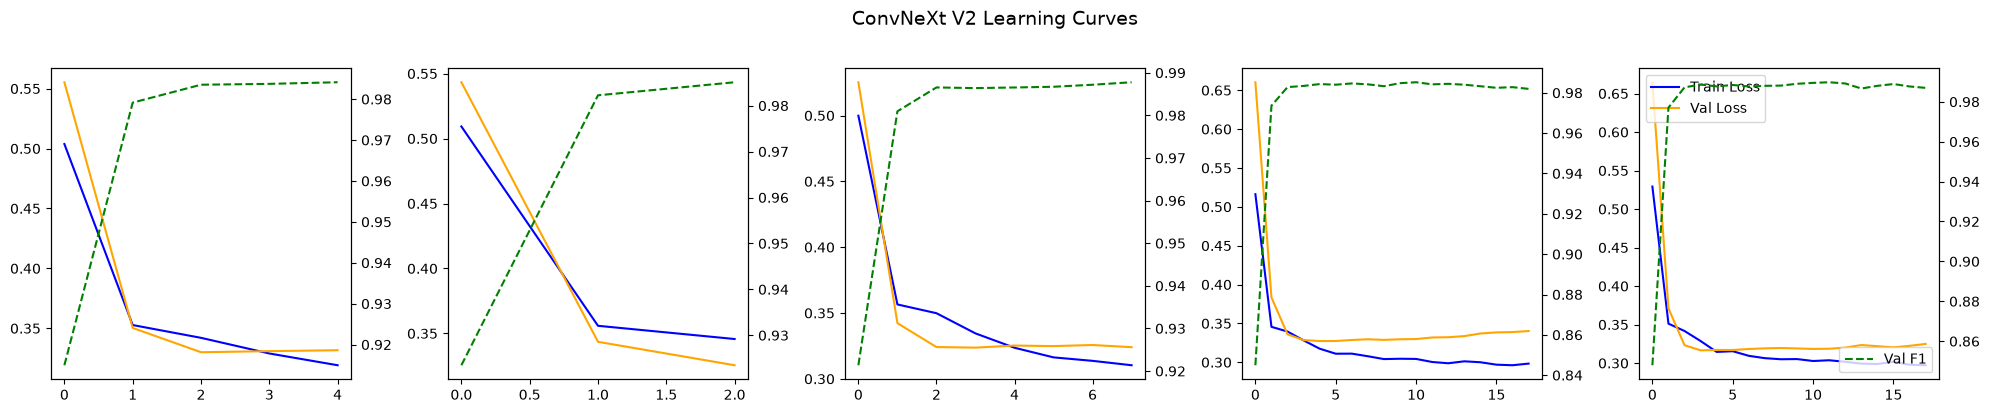


DINOv2 DIAGNOSTICS
Final 5-Fold CV Score (DINOv2): 0.9799 +/- 0.0018



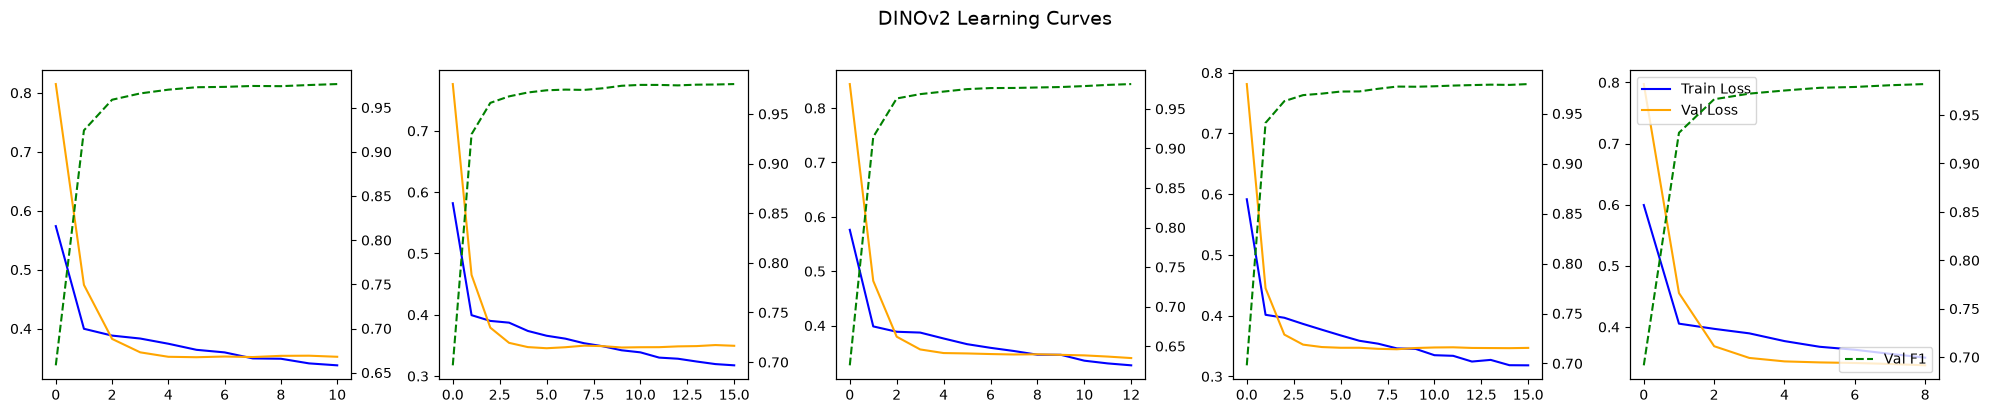

In [24]:
# Cell 22 - CV Results Summary
def plot_cv_results(fold_results, model_name):
    cv_scores = [fold_results[f]["best_f1"] for f in range(N_SPLITS)]
    mean_cv = np.mean(cv_scores)
    std_cv  = np.std(cv_scores)
    print(f"Final 5-Fold CV Score ({model_name}): {mean_cv:.4f} +/- {std_cv:.4f}\n")

    fig, axes = plt.subplots(1, N_SPLITS, figsize=(4 * N_SPLITS, 4))
    for f in range(N_SPLITS):
        ax = axes[f]
        hist = fold_results[f]["history"]
        ax.plot(hist["train_loss"], label="Train Loss", color="blue")
        ax.plot(hist["val_loss"], label="Val Loss", color="orange")
        ax2 = ax.twinx()
        ax2.plot(hist["val_macro_f1"], label="Val F1", color="green", linestyle="--")
        if f == N_SPLITS - 1:
            ax.legend(loc="upper left"); ax2.legend(loc="lower right")
    plt.suptitle(f"{model_name} Learning Curves", fontsize=14, y=1.02)
    plt.tight_layout(); plt.show()

print("CONVNEXT V2 DIAGNOSTICS")
plot_cv_results(convnext_fold_results, "ConvNeXt V2")

print("\nDINOv2 DIAGNOSTICS")
plot_cv_results(vit_fold_results, "DINOv2")

In [25]:
# Cell 23 - OOF Analysis
def analyze_oof(oof_probs, oof_labels, model_name):
    valid_oof_mask = oof_labels != -1
    valid_oof_probs  = oof_probs[valid_oof_mask]
    valid_oof_labels = oof_labels[valid_oof_mask]
    valid_oof_preds  = np.argmax(valid_oof_probs, axis=1)

    print(f"Overall OOF Macro F1 ({model_name}): {f1_score(valid_oof_labels, valid_oof_preds, average='macro'):.4f}\n")

print("CONVNEXT V2 OOF ANALYSIS")
analyze_oof(convnext_oof_probs, convnext_oof_labels, "ConvNeXt V2")

print("\nDINOv2 OOF ANALYSIS")
analyze_oof(vit_oof_probs, vit_oof_labels, "DINOv2")

CONVNEXT V2 OOF ANALYSIS
Overall OOF Macro F1 (ConvNeXt V2): 0.9864


DINOv2 OOF ANALYSIS
Overall OOF Macro F1 (DINOv2): 0.9799



In [39]:
# Cell 23b - Reconstruct SigLIP OOF dari checkpoint fold 0,1,2
print("[INFO] Rekonstruksi SigLIP OOF...")
n_train = len(train_master)
sig_oof_probs  = np.zeros((n_train, 3), dtype=np.float32)
sig_oof_labels = np.full(n_train, -1, dtype=np.int64)
_, siglip_tfms = get_transforms_clip(IMG_SIZE_SIG)  # ambil eval_tfm

for fold in range(N_SPLITS):
    ckpt_path = OUTPUT_DIR / f"siglip_fold{fold}_best.pt"
    if not ckpt_path.exists() or ckpt_path.stat().st_size < 1024:
        print(f"[SKIP] Fold {fold}: tidak ada checkpoint."); continue
    val_df  = train_master[train_master["fold"] == fold].reset_index()
    val_idx = train_master[train_master["fold"] == fold].index.tolist()
    print(f"[LOAD] Fold {fold}: {len(val_df)} sampel...")
    model = build_model(MODEL_NAME_SIG, pretrained=False, img_size=IMG_SIZE_SIG)
    sd = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(sd["model_state_dict"] if "model_state_dict" in sd else sd)
    model.eval().to(DEVICE)
    val_ds = WasteDataset(val_df, transform=siglip_tfms)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE_SIG, shuffle=False, num_workers=2, pin_memory=True)
    fp, fl = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            with torch.amp.autocast('cuda'):
                probs = torch.softmax(model(imgs.to(DEVICE)), dim=1).cpu().numpy()
            fp.append(probs); fl.extend(labels.numpy())
    fp = np.concatenate(fp)
    for i, orig_idx in enumerate(val_idx):
        sig_oof_probs[orig_idx] = fp[i]; sig_oof_labels[orig_idx] = fl[i]
    del model; torch.cuda.empty_cache()
    print(f"[DONE] Fold {fold} selesai.")

print(f"[DONE] {(sig_oof_probs.sum(axis=1)>0).sum()} sampel OOF SigLIP berhasil direkonstruksi.")

[INFO] Rekonstruksi SigLIP OOF...
[LOAD] Fold 0: 5275 sampel...
[DONE] Fold 0 selesai.
[LOAD] Fold 1: 5275 sampel...
[DONE] Fold 1 selesai.
[LOAD] Fold 2: 5276 sampel...
[DONE] Fold 2 selesai.
[SKIP] Fold 3: tidak ada checkpoint.
[SKIP] Fold 4: tidak ada checkpoint.
[DONE] 15826 sampel OOF SigLIP berhasil direkonstruksi.


In [40]:
# Cell 24 - Nelder-Mead 4D pakai OOF SigLIP real dari 3 fold
from scipy.optimize import minimize

valid_mask = (convnext_oof_labels != -1) & (sig_oof_probs.sum(axis=1) > 0)
oc     = convnext_oof_probs[valid_mask]
ov     = vit_oof_probs[valid_mask]
oe     = eva_oof_probs[valid_mask]
o_sig  = sig_oof_probs[valid_mask]
y_true = convnext_oof_labels[valid_mask]
print(f"[INFO] Nelder-Mead 4D menggunakan {valid_mask.sum()} sampel OOF SigLIP.")

def neg_f1_4model(w):
    w1, w2, w3 = w[0], w[1], w[2]
    w4 = 1.0 - w1 - w2 - w3
    if any(x <= 0 for x in [w1, w2, w3, w4]): return 0.0
    preds = np.argmax(w1*oc + w2*ov + w3*oe + w4*o_sig, axis=1)
    return -f1_score(y_true, preds, average="macro")

best_res = None
for x0 in [[0.25, 0.20, 0.28], [0.30, 0.15, 0.25], [0.25, 0.25, 0.25]]:
    res = minimize(neg_f1_4model, x0=x0, method="Nelder-Mead", options={"xatol":1e-7, "fatol":1e-7, "maxiter":5000})
    if best_res is None or res.fun < best_res.fun: best_res = res

W_CNN = round(float(best_res.x[0]), 4)
W_VIT = round(float(best_res.x[1]), 4)
W_EVA = round(float(best_res.x[2]), 4)
W_SIG = round(float(1.0 - W_CNN - W_VIT - W_EVA), 4)
print(f"OPTIMAL 4-MODEL WEIGHTS:")
print(f"  ConvNeXt-512 : {W_CNN:.4f}")
print(f"  DINOv2-Small : {W_VIT:.4f}")
print(f"  EVA-02-Base  : {W_EVA:.4f}")
print(f"  SigLIP-SO400M: {W_SIG:.4f}")
print(f"  4-Model OOF Macro F1: {-best_res.fun:.4f}")

[INFO] Nelder-Mead 4D menggunakan 9556 sampel OOF SigLIP.
OPTIMAL 4-MODEL WEIGHTS:
  ConvNeXt-512 : 0.3100
  DINOv2-Small : 0.1550
  EVA-02-Base  : 0.2375
  SigLIP-SO400M: 0.2975
  4-Model OOF Macro F1: 0.9881


In [30]:
# Cell 25 - TTA Transforms & Memory Pre-loader
def get_tta_transforms(img_size, model_type="cnn", clip_norm=False):
    if clip_norm:
        mean, std = [0.5, 0.5, 0.5], [0.5, 0.5, 0.5]
    else:
        mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
        
    normalize = T.Normalize(mean, std)
    base_resize = T.Resize((img_size, img_size), interpolation=InterpolationMode.BICUBIC)
    to_tensor = T.ToTensor()

    def p(img): return normalize(to_tensor(base_resize(img)))
    def p0_orig(img):     return p(img)
    def p1_hflip(img):    return p(TF.hflip(img))
    def p2_vflip(img):    return p(TF.vflip(img))
    def p3_rot90(img):    return p(TF.rotate(img, 90))
    def p4_rot180(img):   return p(TF.rotate(img, 180))
    def p5_rot270(img):   return p(TF.rotate(img, 270))
    def p6_crop(img):
        w, h = img.size
        return p(TF.center_crop(img, int(min(w, h) * 0.9)))
    def p7_crop_hf(img):
        w, h = img.size
        return p(TF.hflip(TF.center_crop(img, int(min(w, h) * 0.9))))

    if model_type == "cnn":
        return [('orig', p0_orig), ('hflip', p1_hflip), ('vflip', p2_vflip), ('rot90', p3_rot90), ('rot180', p4_rot180), ('rot270', p5_rot270), ('crop', p6_crop), ('crop_hf', p7_crop_hf)]
    elif model_type == "vit":
        return [('orig', p0_orig), ('hflip', p1_hflip), ('vflip', p2_vflip), ('crop', p6_crop), ('crop_hf', p7_crop_hf)]
    else: raise ValueError(f"Unknown model_type for TTA: {model_type}")
    
print("Pre-loading test images into memory...")
test_pil_images = []
for idx, row in submission_df.iterrows():
    try:
        img = Image.open(row["filepath"]).convert('RGB')
    except Exception as e:
        img = Image.new('RGB', (IMG_SIZE_CNN, IMG_SIZE_CNN), (0, 0, 0))
    test_pil_images.append(img)
print(f"Loaded {len(test_pil_images)} test images into memory.")

class PreloadedTTADataset(Dataset):
    def __init__(self, images, transform):
        self.images = images
        self.transform = transform
    def __len__(self): return len(self.images)
    def __getitem__(self, i): return self.transform(self.images[i])

Pre-loading test images into memory...
Loaded 1458 test images into memory.


In [33]:
# Cell 26 - TTA Runner [FINAL PATCH]
@torch.no_grad()
def run_tta_inference(model_name, img_size, prefix, batch_size, model_type, clip_norm=False):
    tta_tfms = get_tta_transforms(img_size, model_type, clip_norm=clip_norm)

    chkpt_paths = [c for c in [OUTPUT_DIR / f"{prefix}_fold{fold}_best.pt" for fold in range(N_SPLITS)] if c.exists() and c.stat().st_size > 1024]
    if len(chkpt_paths) == 0:
        raise FileNotFoundError(f'[ERROR] Tidak ada checkpoint untuk {prefix}')
    print(f"[INFO] {prefix} TTA: ditemukan {len(chkpt_paths)}/{N_SPLITS} checkpoint(s).")

    all_probs = np.zeros((len(submission_df), 3), dtype=np.float32)
    folds_used = 0

    for chkpt in chkpt_paths:
        fold = int(chkpt.stem.split("fold")[1].split("_")[0])
        print(f"[LOAD] Running {len(tta_tfms)}-Pass TTA for {prefix} Fold {fold}...")

        try:
            # CNN tidak support img_size di timm, ViT support
            if model_type == "cnn":
                model = build_model(model_name, pretrained=False)
            else:
                model = build_model(model_name, pretrained=False, img_size=img_size)

            state_dict = torch.load(chkpt, map_location=DEVICE, weights_only=False)
            if "model_state_dict" in state_dict:
                model.load_state_dict(state_dict["model_state_dict"])
            else:
                model.load_state_dict(state_dict)
        except Exception as _e:
            print(f"[RECOVER] {prefix} fold {fold} load failed: {_e}. Skipping.")
            continue

        model.eval().to(DEVICE)
        fold_probs = np.zeros((len(submission_df), 3), dtype=np.float32)

        for name, tfm in tta_tfms:
            loader = DataLoader(
                PreloadedTTADataset(test_pil_images, tfm),
                batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True,
            )
            pass_probs = []
            for imgs in loader:
                with torch.amp.autocast('cuda'):
                    probs = torch.softmax(model(imgs.to(DEVICE)), dim=1)
                pass_probs.append(probs.cpu().numpy())
            fold_probs += np.concatenate(pass_probs, axis=0)

        fold_probs /= len(tta_tfms)
        all_probs += fold_probs
        folds_used += 1
        del model
        torch.cuda.empty_cache()

    if folds_used == 0:
        raise RuntimeError(f'[ERROR] {prefix} TTA: semua fold gagal load.')
    if folds_used < N_SPLITS:
        print(f'[WARNING] {prefix} TTA: only {folds_used}/{N_SPLITS} folds loaded.')
    all_probs /= folds_used
    print(f'[FOUND] {prefix} TTA complete using {folds_used}/{N_SPLITS} folds.')
    return all_probs

In [34]:
# Cell 27 - EXECUTION: ConvNeXt TTA
print('[LOAD] Extracting ConvNeXt probabilities...')
probs_convnext = run_tta_inference(
    model_name=MODEL_NAME_CNN, img_size=IMG_SIZE_CNN, prefix="convnext",
    batch_size=BATCH_SIZE_CNN, model_type="cnn"
)
np.save(OUTPUT_DIR / "probs_convnext.npy", probs_convnext)
print('[FOUND] probs_convnext.npy saved.')

[LOAD] Extracting ConvNeXt probabilities...
[INFO] convnext TTA: ditemukan 5/5 checkpoint(s).
[LOAD] Running 8-Pass TTA for convnext Fold 0...
[LOAD] Running 8-Pass TTA for convnext Fold 1...
[LOAD] Running 8-Pass TTA for convnext Fold 2...
[LOAD] Running 8-Pass TTA for convnext Fold 3...
[LOAD] Running 8-Pass TTA for convnext Fold 4...
[FOUND] convnext TTA complete using 5/5 folds.
[FOUND] probs_convnext.npy saved.


In [41]:
# Cell 28 - EXECUTION: DINOv2 TTA
# [PATCH 2] Multi-path fallback: copy DINOv2 checkpoints to OUTPUT_DIR if needed
for fold in range(N_SPLITS):
    out_ckpt = OUTPUT_DIR / f'dinov2_fold{fold}_best.pt'
    if not out_ckpt.exists() or out_ckpt.stat().st_size < 1024:
        _candidates = [
            DATA_DIR / f'dinov2_fold{fold}_best.pt',
            Path('.') / f'dinov2_fold{fold}_best.pt',
            Path('.') / 'dinov2' / f'dinov2_fold{fold}_best.pt',
            DATA_DIR.parent / 'dinov2' / f'dinov2_fold{fold}_best.pt',
        ]
        _src = next((p for p in _candidates if p.exists() and p.stat().st_size > 1024), None)
        if _src:
            import shutil as _shutil_t
            _shutil_t.copy2(_src, out_ckpt)
            print(f'[LOAD] Copied DINOv2 fold {fold} from {_src} to OUTPUT_DIR.')
        else:
            print(f'[WARNING] DINOv2 fold {fold} checkpoint not found in any search path.')

print('[LOAD] Extracting DINOv2 probabilities...')
probs_dinov2 = run_tta_inference(
    model_name=MODEL_NAME_VIT, img_size=IMG_SIZE_VIT, prefix='dinov2',
    batch_size=BATCH_SIZE_VIT, model_type='vit'
)
np.save(OUTPUT_DIR / 'probs_dinov2.npy', probs_dinov2)
print('[FOUND] probs_dinov2.npy saved.')

[LOAD] Extracting DINOv2 probabilities...
[INFO] dinov2 TTA: ditemukan 5/5 checkpoint(s).
[LOAD] Running 5-Pass TTA for dinov2 Fold 0...
[LOAD] Running 5-Pass TTA for dinov2 Fold 1...
[LOAD] Running 5-Pass TTA for dinov2 Fold 2...
[LOAD] Running 5-Pass TTA for dinov2 Fold 3...
[LOAD] Running 5-Pass TTA for dinov2 Fold 4...
[FOUND] dinov2 TTA complete using 5/5 folds.
[FOUND] probs_dinov2.npy saved.


In [42]:
# Cell 29 - EXECUTION: EVA-02 TTA
print('[LOAD] Extracting EVA-02 probabilities (CLIP norm)...')
probs_eva02 = run_tta_inference(
    model_name=MODEL_NAME_EVA, img_size=IMG_SIZE_EVA, prefix="eva02",
    batch_size=BATCH_SIZE_EVA, model_type="vit", clip_norm=True
)
np.save(OUTPUT_DIR / "probs_eva02.npy", probs_eva02)
print('[FOUND] probs_eva02.npy saved.')

[LOAD] Extracting EVA-02 probabilities (CLIP norm)...
[INFO] eva02 TTA: ditemukan 5/5 checkpoint(s).
[LOAD] Running 5-Pass TTA for eva02 Fold 0...
[LOAD] Running 5-Pass TTA for eva02 Fold 1...
[LOAD] Running 5-Pass TTA for eva02 Fold 2...
[LOAD] Running 5-Pass TTA for eva02 Fold 3...
[LOAD] Running 5-Pass TTA for eva02 Fold 4...
[FOUND] eva02 TTA complete using 5/5 folds.
[FOUND] probs_eva02.npy saved.


In [ ]:
# Cell 30 - EXECUTION: SigLIP-SO400M TTA (3/3 fold)
_orig = N_SPLITS
N_SPLITS = 3  # SigLIP hanya 3 fold
print('[LOAD] Extracting SigLIP-SO400M probabilities (CLIP norm)...')
probs_siglip = run_tta_inference(
    model_name=MODEL_NAME_SIG, img_size=IMG_SIZE_SIG, prefix="siglip",
    batch_size=BATCH_SIZE_SIG, model_type="vit", clip_norm=True
)
N_SPLITS = _orig  # Restore ke 5
np.save(OUTPUT_DIR / "probs_siglip.npy", probs_siglip)
print('[FOUND] probs_siglip.npy saved.')

[LOAD] Extracting SigLIP-SO400M probabilities (CLIP norm)...
[INFO] siglip TTA: ditemukan 3/3 checkpoint(s).
[LOAD] Running 5-Pass TTA for siglip Fold 0...


In [44]:
# Cell 31 - 4-Model Ensemble Averaging & Hash Override
if not (OUTPUT_DIR / "probs_siglip.npy").exists():
    print("WARNING: SigLIP probs missing, using EVA-02 fallback")
    probs_siglip = probs_eva02
else:
    probs_siglip = np.load(OUTPUT_DIR / "probs_siglip.npy")

ensemble_probs = (W_CNN * probs_convnext) + (W_VIT * probs_dinov2) + (W_EVA * probs_eva02) + (W_SIG * probs_siglip)
predictions    = np.argmax(ensemble_probs, axis=1)

override_map = {}
override_count = 0

if OVERLAP_CSV.exists():
    overlap_df = pd.read_csv(OVERLAP_CSV)
    for _, r in overlap_df.iterrows():
        img_id = int(r["test_id"])
        idx = img_id - 1
        label = LABEL_TO_IDX[r["train_label"]]
        predictions[idx] = label
        override_map[img_id] = label
        override_count += 1
    print(f"[FOUND] Applied {override_count} MD5 hash overrides successfully.")
else:
    print("[WARNING] No overlap CSV found. Skipping hash overrides.")

[FOUND] Applied 97 MD5 hash overrides successfully.


In [45]:
# Cell 32 - Pre-Submission Validation
assert len(predictions) == EXPECTED_TEST_COUNT
assert list(submission_df["id"]) == list(range(1, EXPECTED_TEST_COUNT + 1))

for idx, row in submission_df.iterrows():
    img_id = int(row["id"])
    if img_id in override_map:
        assert predictions[idx] == override_map[img_id], f"Override failed for ID {img_id}"

pred_dist = pd.Series(predictions).value_counts(normalize=True).sort_index()
valid_train = train_master[(~train_master["exclude_from_cv"]) & (~train_master["exclude_from_training"])]
train_dist = valid_train["label"].value_counts(normalize=True).sort_index()
dist_shift = (pred_dist - train_dist).abs()

print("Prediction vs Training distribution:")
for i, name in LABEL_MAP.items():
    print(f"{name:<14} Train: {train_dist[i]:<8.1%} Pred: {pred_dist[i]:<8.1%} Shift: {dist_shift[i]:<8.1%}")

print("\nALL PRE-SUBMISSION SANITY CHECKS PASSED.")

Prediction vs Training distribution:
Recyclable     Train: 37.9%    Pred: 35.7%    Shift: 2.3%    
Electronic     Train: 15.0%    Pred: 13.7%    Shift: 1.3%    
Organic        Train: 47.1%    Pred: 50.6%    Shift: 3.6%    

ALL PRE-SUBMISSION SANITY CHECKS PASSED.


In [46]:
# Cell 33 - Generate Final Submission CSV
submission_df["predicted"] = predictions
output_path = OUTPUT_DIR / "EVA02 DinoV2 ConvNeXT Siglip.csv"

final_df = submission_df[["id", "predicted"]].copy()
final_df.to_csv(output_path, index=False)

print(f"FINAL SUBMISSION SAVED: {output_path}")
print("\nFinal Prediction Distribution:")
for lbl, cnt in final_df["predicted"].value_counts().sort_index().items():
    print(f"  {LABEL_MAP[lbl]:12s}: {cnt:4,} ({cnt/EXPECTED_TEST_COUNT:.1%})")

with open(output_path, "rb") as f:
    file_hash = hashlib.md5(f.read()).hexdigest()

submission_metadata = {
    "run_id": RUN_ID,
    "convnext": {"model": MODEL_NAME_CNN, "img_size": IMG_SIZE_CNN, "cv": float(np.mean([r['best_f1'] for r in convnext_fold_results.values()]))},
    "dinov2":   {"model": MODEL_NAME_VIT, "img_size": IMG_SIZE_VIT, "cv": float(np.mean([r['best_f1'] for r in vit_fold_results.values()]))},
    "eva02":    {"model": MODEL_NAME_EVA, "img_size": IMG_SIZE_EVA, "cv": float(np.mean([r['best_f1'] for r in eva_fold_results.values()]))},
    "weights":  {"convnext": float(W_CNN), "dinov2": float(W_VIT), "eva02": float(W_EVA)},
    "overrides_applied": override_count,
}
with open(OUTPUT_DIR / "submission_metadata.json", "w") as f:
    json.dump(submission_metadata, f, indent=2)

FINAL SUBMISSION SAVED: /workspace/satria-data-bdc/outputs/EVA02 DinoV2 ConvNeXT Siglip.csv

Final Prediction Distribution:
  Recyclable  :  520 (35.7%)
  Electronic  :  200 (13.7%)
  Organic     :  738 (50.6%)


In [47]:
# Cell 34 - OOF Error Analysis DataFrame Generation
oof_df = train_master.copy()
oof_probs_ensemble = (ENSEMBLE_WEIGHT_CNN * convnext_oof_probs) + (ENSEMBLE_WEIGHT_VIT * vit_oof_probs)

oof_df['pred_label'] = np.argmax(oof_probs_ensemble, axis=1)
oof_df['pred_confidence'] = np.max(oof_probs_ensemble, axis=1)
oof_df['gt_prob'] = oof_probs_ensemble[np.arange(len(oof_df)), oof_df['label']]

oof_df = oof_df[(oof_df['exclude_from_training'] == False) & (oof_df['exclude_from_cv'] == False)].copy()
oof_df['is_correct'] = oof_df['pred_label'] == oof_df['label']
oof_df['is_relabeled'] = oof_df['label_folder'].map(LABEL_TO_IDX) != oof_df['label']
print(f"OOF Analysis DataFrame generated. Total evaluated rows: {len(oof_df)}")

OOF Analysis DataFrame generated. Total evaluated rows: 26374


In [48]:
# Cell 35 - Save OOF High-Confidence Errors
errors_df = oof_df[~oof_df['is_correct']].copy()
errors_df = errors_df.sort_values(by='pred_confidence', ascending=False)

error_report = errors_df[[
    'filename', 'filepath', 'label_folder', 'label', 'pred_label', 'pred_confidence', 'gt_prob', 'is_relabeled'
]].rename(columns={
    'label_folder': 'original_label_folder', 'label': 'current_label', 'pred_label': 'oof_pred'
})

output_csv = OUTPUT_DIR / "oof_high_confidence_errors.csv"
error_report.to_csv(output_csv, index=False)

print(f"Saved {len(error_report)} OOF errors to {output_csv}.")
print("\nTop 15 highest confidence OOF errors:")
print(error_report.head(15).to_string(index=False))

Saved 466 OOF errors to /workspace/satria-data-bdc/outputs/oof_high_confidence_errors.csv.

Top 15 highest confidence OOF errors:
                            filename                                                                           filepath original_label_folder  current_label  oof_pred  pred_confidence  gt_prob  is_relabeled
59.AdobeStock_500968458-800x250.jpeg /workspace/satria-data-bdc/train/1_Electronic/59.AdobeStock_500968458-800x250.jpeg          1_Electronic              1         0         0.564113 0.017174         False
                           O_512.jpg                               /workspace/satria-data-bdc/train/2_Organic/O_512.jpg             2_Organic              2         0         0.563031 0.018973         False
                          O_1773.jpg                              /workspace/satria-data-bdc/train/2_Organic/O_1773.jpg             2_Organic              2         0         0.562525 0.017376         False
                          O_9785.jpg      